## FIT1043 Assignment2 HanSiYi 33396973

## Part A: Classification

### A1. Supervised Learning

### A1.1

#### Supervised machine learning:

Supervised learning is a machine learning method where the system develops an understanding of the features from labelled training data. In supervised learning, the data includes both features and labels, allowing the machine to independently learn the association between them. Through supervised training, the system identifies patterns between features and labels from this known relationship, leading to the creation of an optimal model. 

#### https://www.datacamp.com/blog/supervised-machine-learning   - Reference

#### The notion of labelled data:

Labelled data can be understood as the output values, dependent variables, or targets within a dataset. These labels may take the form of continuous values for regression problems, or discrete values for classification challenges. Typically represented by the variable y, the label is the key variable that we aim to predict. It embodies the outcomes or predictions that we strive to ascertain through our analytical models.

#### https://www.datacamp.com/blog/what-is-labeled-data     - Reference

#### Train and test datasets:

Data is typically divided into two subsets: a training set and a test set. 
The model is trained using the training set data. During training, the model learns the relationships between the features and the corresponding labels. The parameters of the model, such as weights and biases, are determined during this process. 
After training is complete, the model is tested on the test set. 
The error on the test set is used to approximate the generalization error of the model in real-world scenarios. The training set is used to train the model and determine its parameters, often referred to as learning parameters. 
The test set is used only once, for evaluating the final model after training. 
It does not participate in the learning or hyperparameter selection processes. 
A common practice is to use a 75%/25% split ratio, where 75% of the data is used for training and 25% for testing. However, the specific ratio may vary depending on the dataset size and requirements.


#### https://testsigma.com/blog/difference-between-training-data-and-testing-data/    - Reference

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline

### A1.2

In [2]:
df = pd.read_csv('FIT1043-MusicGenre-Dataset.csv')
df.describe()    # Get the column name and the data to decide choose which features.

,instance_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,music_genre
count,25958.000000,25958.000000,25958.000000,25958.000000,2.595800e+04,25958.000000,25958.000000,25958.000000,25958.000000,25958.000000,25958.000000,25958.000000,25958.000000
mean,55769.941251,44.168541,0.307858,0.557978,2.454655e+05,0.599596,0.182954,0.193972,-9.167320,0.094058,120.003122,0.458558,4.480083
std,20762.395950,15.547882,0.342093,0.178840,1.105926e+05,0.265468,0.326709,0.162042,6.180744,0.102968,30.612044,0.247895,2.870148
min,20005.000000,0.000000,0.000000,0.059600,1.631600e+04,0.000792,0.000000,0.009670,-47.046000,0.022300,34.347000,0.000000,0.000000
25%,37843.500000,34.000000,0.020300,0.442000,1.904285e+05,0.430000,0.000000,0.096900,-10.898000,0.035900,94.986000,0.260000,2.000000
50%,55740.500000,45.000000,0.146000,0.569000,2.275015e+05,0.645000,0.000167,0.126000,-7.293000,0.048700,119.848500,0.451000,4.000000
75%,73777.750000,55.000000,0.553000,0.686000,2.758930e+05,0.817000,0.158000,0.243000,-5.185000,0.098575,140.493750,0.650000,7.000000
max,91759.000000,99.000000,0.996000,0.986000,4.497994e+06,0.999000,0.996000,1.000000,3.744000,0.942000,220.276000,0.989000,9.000000


In [3]:
# Get the datasize to decide how many % test data size.
# To see it is cleaning data or not.
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25958 entries, 0 to 25957
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       25958 non-null  int64  
 1   artist_name       25958 non-null  object 
 2   track_name        25958 non-null  object 
 3   popularity        25958 non-null  int64  
 4   acousticness      25958 non-null  float64
 5   danceability      25958 non-null  float64
 6   duration_ms       25958 non-null  int64  
 7   energy            25958 non-null  float64
 8   instrumentalness  25958 non-null  float64
 9   liveness          25958 non-null  float64
 10  loudness          25958 non-null  float64
 11  speechiness       25958 non-null  float64
 12  tempo             25958 non-null  float64
 13  valence           25958 non-null  float64
 14  music_genre       25958 non-null  int64  
dtypes: float64(9), int64(4), object(2)
memory usage: 3.0+ MB


In [4]:
# Choose label and features
y = df.iloc[:, -1].values  # label: music_genre - the predicted output value, which is also the target variable
X = df.iloc[:, [3, 4, 5, 6, 7, 8, 10, 11, 12, 13]].values  # features: acousticness, energy, instrumentalness, speechiness, tempo, valence

### A1.3

In [5]:
# Follow the applied session given step.
# Change the test_size and the random_state depend on the csv size and state.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### A2.1

#### The difference(s) between binary and multi-class classification:

Binary classification is concerned with distinguishing between two distinct categories, whereas multi-class classification manages the differentiation among three or more unrelated categories. In binary classification, the labels exhibit only two possible outcomes, frequently encoded as 0 or 1. In contrast, multi-class classification involves labels that span three or more mutually exclusive categories. Each label distinctly represents a different category, and each instance is uniquely assigned to a single label.

In the realm of binary classification, metrics such as precision and recall are routinely utilized. For multi-class classification, accuracy, precision, recall, and occasionally confusion matrices are employed to provide a comprehensive overview of performance across all categories.

####  https://www.analyticssteps.com/blogs/binary-and-multiclass-classification-machine-learning      - Reference

### A2.2

####  a)Describe what you understand from this need to normalise data:

Normalizing data is crucial due to the wide variation in data values. Some functions may fail to operate effectively or may exhibit significantly reduced performance when handling such varied data. To ensure a uniform scale and enhance the performance of models, it is necessary to implement normalization. This process helps maintain consistency across the data's scale, leading to more reliable and efficient outcomes in modeling.

In [6]:
# b)Features Scaling 
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### A2.3

#### https://www.geeksforgeeks.org/support-vector-machine-algorithm/       - Reference

#### a)Describe SVM:

Support Vector Machine (SVM) is a machine learning algorithm suitable for binary classification tasks.
It operates by discerning a partitioning hyperplane within the sample space to distinctly separate the samples of different classes.
This algorithm is designed to maximize the minimum distance between the two point sets and this hyperplane, as well as the distance between the boundary points of the point sets and the plane.

For tasks where the data is clearly linearly separable, SVM learns a linear classifier, which is referred to as a hard-margin support vector machine. In scenarios where the training data is approximately linearly separable, it still opts for a linear classifier, known as a soft-margin support vector machine, to handle minor deviations in data separability.
When dealing with training data that is not linearly separable, SVM employs the kernel trick along with soft-margin maximization to learn a nonlinear support vector machine. This approach enables effective classification in more complex and varied data structures.

#### b)In SVM, there is something called the kernel:

Kernel functions are pivotal in enabling Support Vector Machines to handle nonlinear classification by learning complex decision boundaries in high-dimensional spaces. Initially devised for linearly separable problems, SVMs often face real-world data that are not linearly separable. By utilizing kernel functions, SVMs can effectively map input features to a higher-dimensional space where the nonlinear relationships in the original feature space become linearly separable. This technique allows SVMs to perform calculations of inner products in the high-dimensional space directly within the original feature space, sidestepping the computational complexity associated with high-dimensional operations.

In [7]:
# c) build a predict SVM model 
from sklearn.svm import SVC
classifier_svm = SVC(kernel = 'rbf', random_state = 42)
classifier_svm.fit(X_train, y_train)

SVC(random_state=42)

### A2.4

In [8]:
# using Random Forest
from sklearn.ensemble import RandomForestClassifier
classifier_rf = RandomForestClassifier(oob_score=True, n_estimators = 91, max_depth=400, min_samples_split=25, random_state = 42)
# To check what's parameters Random Forest have, then try to adjust it base on the csv file.
classifier_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=400, min_samples_split=25, n_estimators=91,
                       oob_score=True, random_state=42)

### A3.1

In [9]:
# Predicting the Test set results
y_predict_svm = classifier_svm.predict(X_test)
y_predict_rf = classifier_rf.predict(X_test)

### A3.2

In [10]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_svm = confusion_matrix(y_test, y_predict_svm)
cm_rf = confusion_matrix(y_test, y_predict_rf)

In [11]:
cm_svm

array([[282,   4,   9,   1, 138,  42,  84,  43,  27, 156],
       [ 22, 542,  57,  63,  25,  30,   0,  10,   0,   5],
       [ 33,  62, 433,  13, 100,  38,   5,  81,   0,  37],
       [ 13,  22,  17, 645,   4,  17,   0,  23,   0,   3],
       [ 57,  16,  41,   0, 445,  13,  25,  56,   6, 137],
       [ 52,  34,  45,   8,  43, 481,  32,  75,   9,  24],
       [ 39,   0,   4,   0,  16,   6, 488,   6, 212,  50],
       [ 21,  10,  95,  61,  41,  92,  17, 358,   1,  33],
       [ 33,   0,   2,   0,  12,   4, 355,   4, 254, 108],
       [ 77,   3,   2,   2,  61,   6,  23,  22,  37, 548]], dtype=int64)

In [12]:
cm_rf

array([[288,   4,  14,   1, 106,  39,  68,  58,  30, 178],
       [ 28, 543,  55,  62,  14,  33,   0,  12,   0,   7],
       [ 36,  62, 427,   6,  80,  45,   6,  96,   1,  43],
       [ 14,  18,  20, 643,   3,  15,   0,  26,   0,   5],
       [ 47,  14,  34,   1, 475,   5,  18,  45,  11, 146],
       [ 58,  30,  66,   9,  34, 444,  20,  94,   8,  40],
       [ 29,   2,   3,   0,   8,   3, 403,   5, 314,  54],
       [ 22,   9,  78,  53,  44,  86,  19, 379,   2,  37],
       [ 24,   1,   1,   0,   5,   5, 375,   4, 258,  99],
       [ 61,   2,   2,   1,  42,   2,  31,  17,  41, 582]], dtype=int64)

In [13]:
y_predict_svm = classifier_svm.predict(X_test)
cm_svm = confusion_matrix(y_test, y_predict_svm)
accuracy_svm = np.trace(cm_svm) / np.sum(cm_svm) 
accuracy_svm   # SVM - accuracy

0.5747303543913713

In [14]:
y_predict_rf = classifier_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_predict_rf)
accuracy_rf = np.trace(cm_rf) / np.sum(cm_rf)
accuracy_rf    # Random Forest - accuracy

0.5703646635850026

In [15]:
from sklearn.metrics import f1_score
f1_score(y_test, y_predict_svm, average='weighted')   # SVM - F1 score

0.5708275212890312

In [16]:
f1_score(y_test, y_predict_rf, average='weighted')     # Random Forest - F1 score

0.5679294492152219

### A3.3

Support Vector Machine outperforms Random Forest in terms of both Accuracy and F1 score. Specifically, the accuracy of SVM is 56.45%, which is higher than that of Random Forest at 52.71%. Similarly, the F1 score for SVM is 55.88%, surpassing the 52.53% achieved by Random Forest. This indicates that SVM provides superior classification performance across these two critical metrics.

### A4.1

In [17]:
# Read csv file
df_sub = pd.read_csv('FIT1043-MusicGenre-Submission.csv')

In [18]:
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6490 entries, 0 to 6489
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       6490 non-null   int64  
 1   artist_name       6490 non-null   object 
 2   track_name        6490 non-null   object 
 3   popularity        6490 non-null   int64  
 4   acousticness      6490 non-null   float64
 5   danceability      6490 non-null   float64
 6   duration_ms       6490 non-null   int64  
 7   energy            6490 non-null   float64
 8   instrumentalness  6490 non-null   float64
 9   liveness          6490 non-null   float64
 10  loudness          6490 non-null   float64
 11  speechiness       6490 non-null   float64
 12  tempo             6490 non-null   float64
 13  valence           6490 non-null   float64
dtypes: float64(9), int64(3), object(2)
memory usage: 710.0+ KB


In [19]:
df_sub.describe()

,instance_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,6490.000000,6490.000000,6490.000000,6490.000000,6.490000e+03,6490.000000,6490.000000,6490.000000,6490.000000,6490.000000,6490.000000,6490.000000
mean,56216.161325,44.516641,0.298338,0.559371,2.453563e+05,0.603454,0.173999,0.195941,-8.991278,0.092748,119.704201,0.454919
std,20509.403698,15.597538,0.336891,0.176752,1.074548e+05,0.261399,0.320203,0.165298,6.122134,0.099017,30.610735,0.246015
min,20009.000000,0.000000,0.000002,0.061400,1.550900e+04,0.000795,0.000000,0.019400,-44.406000,0.022400,37.114000,0.023400
25%,38718.750000,34.000000,0.018925,0.443000,1.904598e+05,0.440000,0.000000,0.096900,-10.636750,0.036000,94.076000,0.254000
50%,56462.500000,45.000000,0.139000,0.567000,2.263200e+05,0.645000,0.000118,0.127000,-7.169000,0.049000,119.943500,0.447000
75%,73993.000000,56.000000,0.532750,0.687000,2.731468e+05,0.815000,0.120000,0.245750,-5.084250,0.099475,140.112000,0.645000
max,91747.000000,92.000000,0.996000,0.971000,1.607333e+06,0.999000,0.983000,0.989000,1.585000,0.795000,213.038000,0.985000


In [20]:
# Use the best model(SVM) which is built earlier to predict 'music_genre'
# Repeat the SVM steps I already done in the before cells. 
# And use .to_csv output a csv file which is I should upload in the Kaggle.
X_sub = df_sub.iloc[:, [3, 4, 5, 6, 7, 8, 10, 11, 12, 13]].values 
X_sub = sc.fit_transform(X_sub)  # Scaled data
sub_predict = classifier_svm.predict(X_sub)

new_df_sub = pd.DataFrame({
    'instance_id': df_sub['instance_id'],
    'music_genre': sub_predict
})

new_df_sub.to_csv('33396973-HanSiYi.csv', index = False)

## Part B

### B1

#### Overwatch 2 statistics
#### https://www.kaggle.com/datasets/mykhailokachan/overwatch-2-statistics

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('ow2_quickplay_heroes_stats__2023-05-06.csv')
missing_data = df.isnull().sum()
missing_data         # There have missing data 

Hero                             0
Skill Tier                       0
KDA Ratio                        0
Pick Rate, %                     0
Win Rate, %                      0
                              ... 
Focusing Beam Kills / 10min    280
Sticky Bomb Accuracy, %        280
Sticky Bomb Kills / 10min      280
Duplicate Kills / 10min        280
Role                             0
Length: 131, dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Columns: 131 entries, Hero to Role
dtypes: float64(126), int64(2), object(3)
memory usage: 294.9+ KB


In [24]:
df.dtypes      # There have numerical features.  

Hero                            object
Skill Tier                      object
KDA Ratio                      float64
Pick Rate, %                   float64
Win Rate, %                    float64
                                ...   
Focusing Beam Kills / 10min    float64
Sticky Bomb Accuracy, %        float64
Sticky Bomb Kills / 10min      float64
Duplicate Kills / 10min        float64
Role                            object
Length: 131, dtype: object

In [25]:
df.describe()

,KDA Ratio,"Pick Rate, %","Win Rate, %",Eliminations / 10min,Objective Kills / 10min,Objective Time / 10min,Damage / 10min,Healing / 10min,Deaths / 10min,"Scoped Accuracy, %",...,Annihilation Kills / 10min,"Jagged Blade Accuracy, %",Carnage Kills / 10min,"Wound Uptime, %",Rampage Kills / 10min,"Focusing Beam Accuracy, %",Focusing Beam Kills / 10min,"Sticky Bomb Accuracy, %",Sticky Bomb Kills / 10min,Duplicate Kills / 10min
count,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,72.000000,288.000000,24.000000,...,8.000000,8.000000,8.000000,8.00000,8.000000,8.000000,8.000000,8.00000,8.000000,8.000000
mean,3.956111,2.750174,49.592326,16.773090,6.407222,67.010417,6496.923611,6789.875000,7.304028,46.208333,...,5.225000,31.625000,7.118750,17.75000,3.493750,38.197500,7.196250,25.87500,8.616250,3.517500
std,1.062053,1.643422,2.764395,3.792898,1.613618,23.865839,2050.593077,2073.630211,0.885774,6.248333,...,0.126829,0.517549,0.231359,0.46291,0.134795,1.037824,0.368896,0.64087,0.310158,0.214193
min,2.250000,0.480000,43.950000,2.150000,0.780000,15.000000,463.000000,1406.000000,5.480000,39.000000,...,5.000000,31.000000,6.740000,17.00000,3.290000,36.880000,6.580000,25.00000,8.100000,3.230000
25%,3.080000,1.677500,48.027500,15.652500,5.520000,50.000000,5325.750000,6895.000000,6.550000,41.000000,...,5.160000,31.000000,6.952500,17.75000,3.387500,37.307500,6.952500,25.75000,8.405000,3.327500
50%,3.805000,2.250000,49.465000,17.850000,6.605000,58.000000,7022.000000,7344.000000,7.365000,44.000000,...,5.285000,32.000000,7.225000,18.00000,3.555000,38.195000,7.360000,26.00000,8.760000,3.565000
75%,4.712500,3.635000,51.312500,19.315000,7.652500,90.000000,7913.750000,7992.250000,8.117500,53.250000,...,5.312500,32.000000,7.297500,18.00000,3.600000,39.127500,7.455000,26.00000,8.850000,3.675000
max,6.720000,9.900000,56.360000,21.080000,8.650000,116.000000,9430.000000,8755.000000,9.190000,56.000000,...,5.340000,32.000000,7.320000,18.00000,3.620000,39.510000,7.560000,27.00000,8.890000,3.790000


In [26]:
# To fill in with the mean value.
for column in ['Pick Rate, %', 'Win Rate, %']:
    mean_value = df[column].mean()
    df[column].fillna(mean_value, inplace=True)

In [27]:
missing_data = df.isnull().sum()
missing_data       # Sucessfully full in.

Hero                             0
Skill Tier                       0
KDA Ratio                        0
Pick Rate, %                     0
Win Rate, %                      0
                              ... 
Focusing Beam Kills / 10min    280
Sticky Bomb Accuracy, %        280
Sticky Bomb Kills / 10min      280
Duplicate Kills / 10min        280
Role                             0
Length: 131, dtype: int64

In [28]:
sc = StandardScaler()
df_scaled = sc.fit_transform(df[['Pick Rate, %', 'Win Rate, %']])

In [29]:
kmeans = KMeans(n_clusters=3, random_state=45).fit(df_scaled)

D:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
D:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [30]:
kmeans.cluster_centers_

array([[ 1.47007846e+00,  7.93501498e-04],
       [-2.64592031e-01, -5.92878007e-01],
       [-6.82552901e-01,  1.19300509e+00]])

In [31]:
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0, 0,
       2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2,
       2, 2])

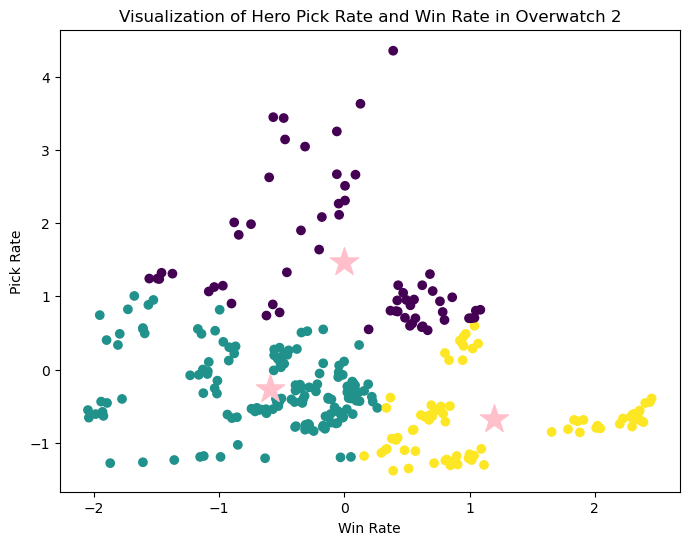

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(x=df_scaled[:, 1], y=df_scaled[:, 0], c=kmeans.labels_)  
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 0], c='pink', s=450,  marker='*') 
plt.title('Visualization of Hero Pick Rate and Win Rate in Overwatch 2')
plt.xlabel('Win Rate')
plt.ylabel('Pick Rate')
plt.show()

K-means clustering is an unsupervised learning technique where data points are grouped into K clusters. Each cluster's center, known as the centroid, represents the average position of all the points in that cluster, not necessarily equidistant from each point. 
From the scatter plot, there are three clusters with three centroids. In the plot, the data points are divided into three different groups,
each group has similar win rates and pick rates. Yellow color and purple color are perform better than green color group.
The green color group has relatively lower pick rate. The game developers can depend on the analysis of scatter plot to detect 
the understanding of player perferences and game balance to adjust the balance of the characters.

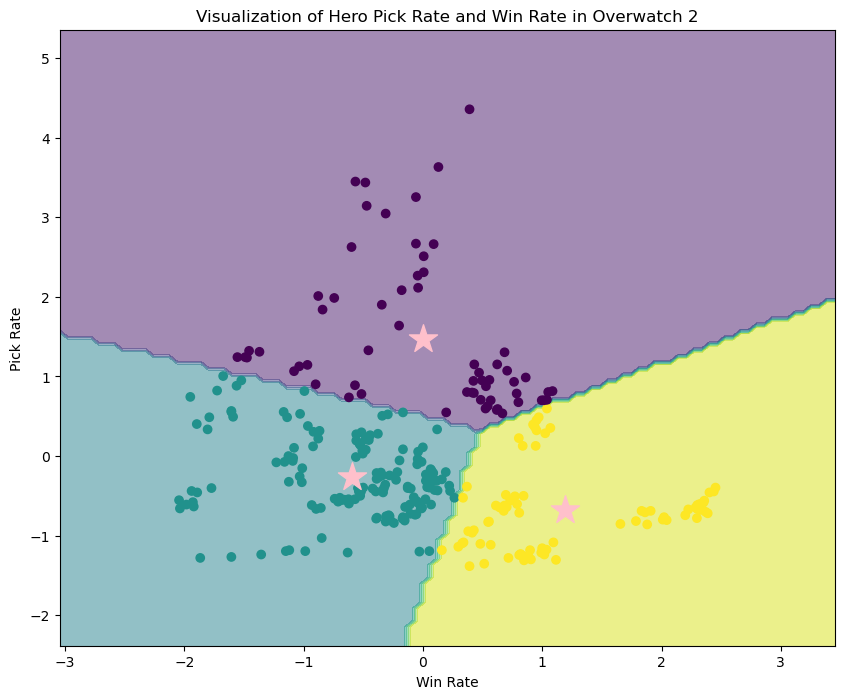

In [33]:
# Create the decision boundaries and generating grid points
x_min, x_max = df_scaled[:, 1].min() - 1, df_scaled[:, 1].max() + 1
y_min, y_max = df_scaled[:, 0].min() - 1, df_scaled[:, 0].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))


Z = kmeans.predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)
# https://zhuanlan.zhihu.com/p/105148901 - reference

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.5)
plt.scatter(df_scaled[:, 1], df_scaled[:, 0], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 0], c='pink', s=450, marker='*')
plt.title('Visualization of Hero Pick Rate and Win Rate in Overwatch 2')
plt.xlabel('Win Rate')
plt.ylabel('Pick Rate')
plt.show()

In the purple color group, the data points with relatively low Win Rate and high Pike Rate. From the location of the cluster center, these characters may be often choose but mediocre performers. In the green color group, Characters' Win Rate and Pick Rate are lower, the charactors are not so popular and normal performance. In the yellow color group, it is higher Win Rate and Lower Pick Rate. May be a "weapon" character who performs well in certain situations and, although not often selected, may have a high win rate once used. If a character belongs to the yellow zone, they may be very valuable in a particular tactic or team combination, although they are usually not selected very often. On the other hand, the character in the purple area, although often selected, may need some improvement or adjustment to improve their performance in the game.

#### Reference: Most parts follow the applied session paper solution.